In [33]:
import pandas as pd
import numpy as np
import requests, random, json
from tqdm import tqdm
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import LedoitWolf


In [34]:

# ---------------------------------------------------------
# Get FULL S&P 500 ticker list
# ---------------------------------------------------------
def get_sp500_tickers():
    # Try yfinance built-in list
    if hasattr(yf, "tickers_sp500"):
        try:
            t = yf.tickers_sp500()
            if t and len(t) >= 400:
                return t
        except:
            pass

    # Fallback 1: DataHub CSV
    try:
        df = pd.read_csv(
            "https://datahub.io/core/s-and-p-500-companies/r/constituents.csv"
        )
        for c in ["Symbol", "Ticker", "Ticker symbol", "Ticker Symbol"]:
            if c in df.columns:
                return df[c].astype(str).str.replace(".", "-", regex=False).tolist()
    except:
        pass

    # Fallback 2: Wikipedia
    html = requests.get(
        "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
        headers={"User-Agent": "Mozilla/5.0"}
    ).text

    tables = pd.read_html(html, header=0)
    for df in tables:
        for c in ["Symbol", "Ticker symbol", "Ticker", "Ticker Symbol"]:
            if c in df.columns:
                return df[c].astype(str).str.replace(".", "-", regex=False).tolist()

    raise RuntimeError("Could not retrieve S&P 500 tickers")

# ---------------------------------------------------------
# Fetch FULL ticker list
# ---------------------------------------------------------
tickers = sorted(set(get_sp500_tickers()))
print(f"Total S&P 500 tickers: {len(tickers)}")

# Optional: save ticker list
with open("sp500_all_tickers.json", "w") as f:
    json.dump(tickers, f, indent=2)

# ---------------------------------------------------------
# Download FULL OHLCV data
# ---------------------------------------------------------
PERIOD = "5y"
INTERVAL = "1d"
BATCH = 50  # safe for Yahoo rate limits

parts = []

for i in tqdm(range(0, len(tickers), BATCH), desc="Downloading S&P 500"):
    batch = tickers[i:i + BATCH]

    df = yf.download(
        batch,
        period=PERIOD,
        interval=INTERVAL,
        group_by="ticker",     # MultiIndex columns (Ticker, OHLCV)
        auto_adjust=False,     # Keep Adj Close
        threads=True,
        progress=False
    )

    if not df.empty:
        parts.append(df)

if not parts:
    raise RuntimeError("No data downloaded. Check internet or rate limits.")

# Combine all batches
data = pd.concat(parts, axis=1)

# Drop tickers with no data at all
data = data.dropna(axis=1, how="all")

# ---------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------
output_file = "sp500_full_ohlcv_5y.csv"
data.to_csv(output_file)

print(f"Saved -> {output_file}")

Total S&P 500 tickers: 503


1 Failed download:
['FI']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')
1 Failed download:
['WBA']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


Saved -> sp500_full_ohlcv_5y.csv


In [35]:
# Load
df = pd.read_csv("sp500_full_ohlcv_5y.csv", header=[0,1], index_col=0, parse_dates=True)
print("Shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
df.head()

Shape: (1256, 3006)
Date range: 2021-01-14 00:00:00 → 2026-01-14 00:00:00


Ticker           ANET                                                        \
Price            Open       High        Low      Close  Adj Close    Volume   
Date                                                                          
2021-01-14  19.500626  20.015938  19.424999  19.568750  19.568750   9076800   
2021-01-15  19.593750  19.971251  19.351749  19.816875  19.816875  11798400   
2021-01-19  19.927500  19.937500  19.516251  19.872499  19.872499   7620800   
2021-01-20  20.021250  20.021250  19.575937  19.653126  19.653126   6363200   
2021-01-21  19.709999  19.811874  19.303499  19.478750  19.478750   6785600   

Ticker            AMD                                   ...         ZTS  \
Price            Open       High        Low      Close  ...         Low   
Date                                                    ...               
2021-01-14  91.769997  92.360001  90.449997  90.790001  ...  160.899994   
2021-01-15  90.750000  91.589996  87.860001  88.209999  ...  159.619995   
2021-01-19  89.559998  89.580002  87.239998  89.449997  ...  161.250000   
2021-01-20  90.550003  90.779999  88.599998  88.750000  ...  161.830002   
2021-01-21  89.339996  92.070000  88.430000  91.529999  ...  162.470001   

Ticker                                              ZBH              \
Price            Close   Adj Close   Volume        Open        High   
Date                                                                  
2021-01-14  160.960007  153.886169  2213900  157.650482  161.097092   
2021-01-15  161.559998  154.459839  2516500  157.456314  157.951462   
2021-01-19  162.570007  155.666321  1464200  156.592239  156.893204   
2021-01-20  163.360001  156.422791  1618000  155.291260  159.339813   
2021-01-21  164.460007  157.476074  2440200  159.291260  160.679611   

Ticker                                                   
Price              Low       Close   Adj Close   Volume  
Date                                                     
2021-01-14  157.650482  157.883499  151.556656  1180071  
2021-01-15  154.883499  155.456314  149.226746  1451476  
2021-01-19  154.650482  155.271851  149.049667  1037828  
2021-01-20  154.087372  158.699036  152.339508  1220035  
2021-01-21  157.796112  158.213593  151.873550  1077483  

[5 rows x 3006 columns]

In [36]:
# Drop columns (tickers) with too many missing values
missing_ratio = df.isna().mean()
df = df.loc[:, missing_ratio < 0.3]  # keep only columns with <30% missing
print("Shape after dropping high-missing columns:", df.shape)

# Fill missing values (forward fill then backfill)
df = df.fillna(method='ffill').fillna(method='bfill')

# Check remaining missing
print("Remaining missing values:", df.isna().sum().sum())

Shape after dropping high-missing columns: (1256, 2976)
Remaining missing values: 0


C:\Users\zubay\AppData\Local\Temp\ipykernel_1088\651265148.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


Total tickers available: 496
Sample tickers selected automatically: ['ANET', 'AMD', 'APO', 'ADSK']

Summary statistics for ANET (Adj Close):
count    1256.000000
mean       59.222190
std        37.557741
min        16.739374
25%        29.441875
50%        42.308750
75%        86.731874
max       162.029999
Name: Adj Close, dtype: float64


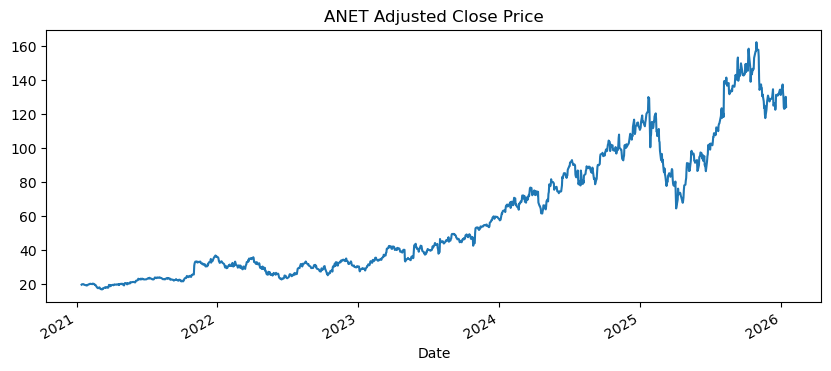

In [37]:
# List all tickers in the dataset
tickers = df.columns.get_level_values(0).unique().tolist()
print(f"Total tickers available: {len(tickers)}")

# Pick the first few tickers automatically
sample_tickers = tickers[:4]   # you can change 4 → any number
print("Sample tickers selected automatically:", sample_tickers)

# Summary stats for the first ticker's Adjusted Close
first_ticker = sample_tickers[0]
print(f"\nSummary statistics for {first_ticker} (Adj Close):")
print(df[first_ticker]['Adj Close'].describe())

# Plot Adjusted Close for the first ticker
df[first_ticker]['Adj Close'].plot(title=f"{first_ticker} Adjusted Close Price", figsize=(10, 4))
plt.show()

In [38]:
# 1) Download SPY with auto-adjusted prices
spy = yf.download(
    "SPY",
    start=df.index.min().strftime("%Y-%m-%d"),
    end=df.index.max().strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False
)

print("SPY columns:", spy.columns)

# 2) Extract the Close price for SPY as a **Series**
# Columns are MultiIndex: (Price, Ticker)
spy_index = spy[("Close", "SPY")]     # this is 1-D series now
spy_index.name = "SPY"

# 3) Align SPY to your main df index
spy_index = spy_index.reindex(df.index).ffill()
index_series = spy_index
index_name = "SPY"

# 4) Get all tickers' Adj Close from your MultiIndex df
adj_close_all = df.xs("Adj Close", level=1, axis=1)  # shape: [dates × tickers]

# 5) Correlation of each ticker vs SPY
corr_vs_spy = adj_close_all.apply(lambda s: s.corr(index_series))
corr_vs_spy_df = corr_vs_spy.to_frame(name="Corr_vs_SPY")

display(corr_vs_spy_df.sort_values("Corr_vs_SPY", ascending=False).head(15))

SPY columns: MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


,Corr_vs_SPY
Ticker,
NVDA,0.984363
AXP,0.981659
HLT,0.979419
JPM,0.977880
PH,0.976597
GE,0.971005
SPG,0.970495
ANET,0.969792
L,0.966900


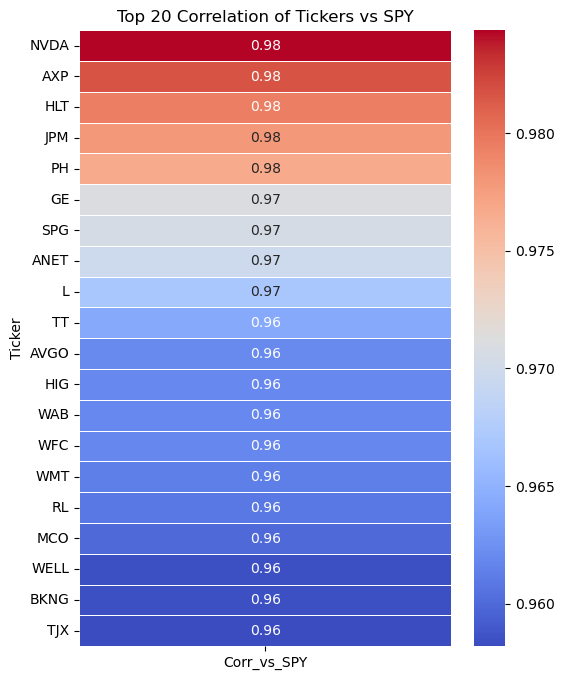

In [39]:
top20 = corr_vs_spy_df.sort_values("Corr_vs_SPY", ascending=False).head(20)

plt.figure(figsize=(6, 8))
sns.heatmap(
    top20,
    cmap="coolwarm",
    annot=True,
    linewidths=0.5
)
plt.title(f"Top 20 Correlation of Tickers vs {index_name}")
plt.show()


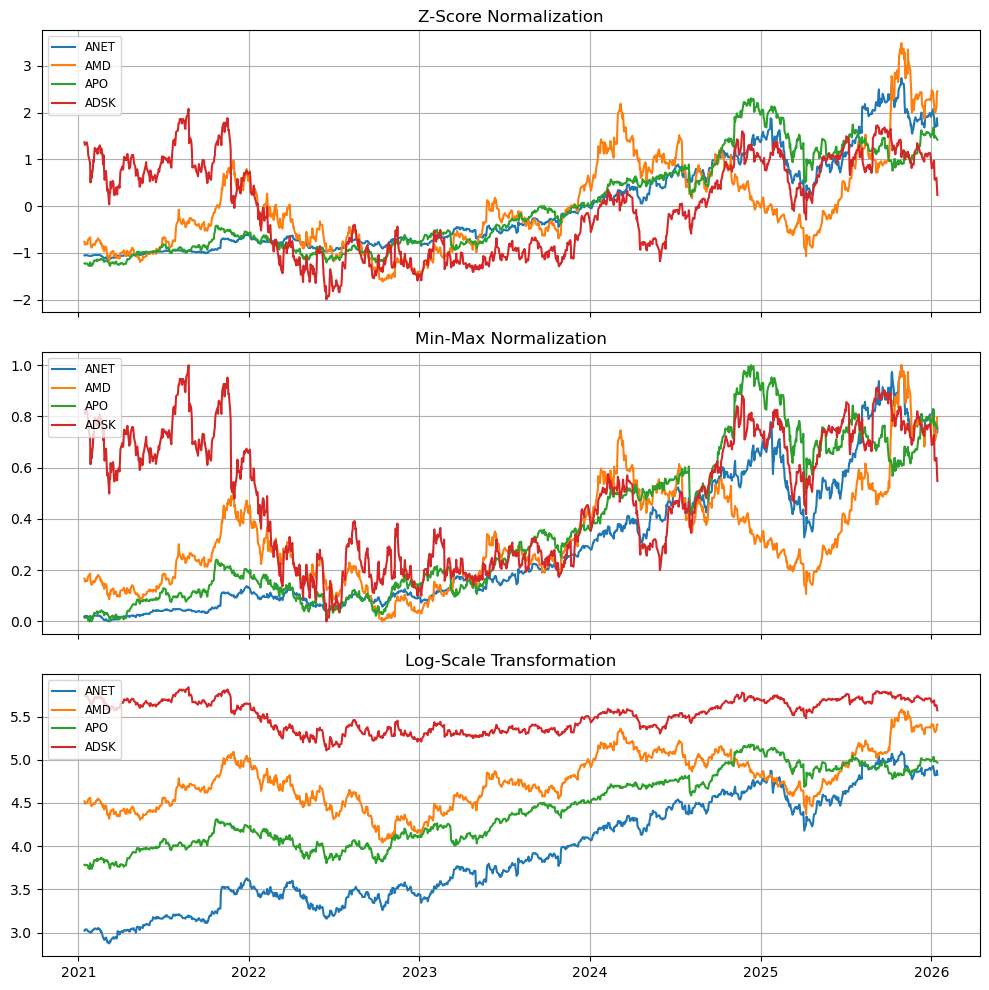

In [40]:
# (a) Z-score normalization
zscore_df = (df - df.mean()) / df.std()

# (b) Min–Max normalization
minmax_df = (df - df.min()) / (df.max() - df.min())

# (c) Log scale
log_df = np.log1p(df)

# ---- Combined plots ----
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot all sample tickers together for each normalization
for ticker in sample_tickers:
    axes[0].plot(zscore_df.index, zscore_df[ticker]['Adj Close'], label=ticker)
    axes[1].plot(minmax_df.index, minmax_df[ticker]['Adj Close'], label=ticker)
    axes[2].plot(log_df.index, log_df[ticker]['Adj Close'], label=ticker)

axes[0].set_title("Z-Score Normalization")
axes[1].set_title("Min-Max Normalization")
axes[2].set_title("Log-Scale Transformation")

for ax in axes:
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True)

plt.tight_layout()
plt.show()

###  Interpretation of Normalization Plots

- **Z-Score Normalization:**  
  This shows how each stock moves compared to its average price.  
  Values above 0 mean the stock is doing better than usual, and below 0 means it’s doing worse.

- **Min–Max Normalization:**  
  This scales all stock prices between 0 and 1.  
  It helps compare different stocks on the same scale even if their prices are very different.

- **Log Scale:**  
  The log scale makes large values smaller and smooths the data.  
  It helps show percentage changes and long-term trends more clearly.


### Smoothing Methods

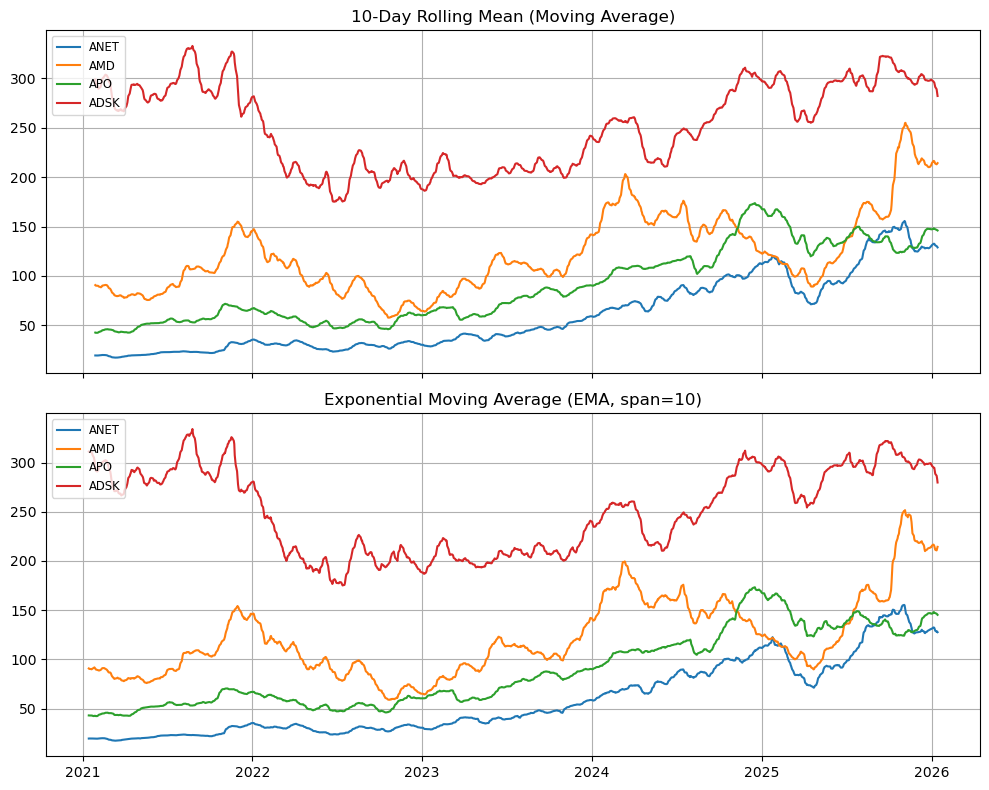

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Rolling Mean (10-day window)
for ticker in sample_tickers:
    axes[0].plot(df.index, df[ticker]['Adj Close'].rolling(window=10).mean(), label=ticker)
axes[0].set_title("10-Day Rolling Mean (Moving Average)")
axes[0].legend(loc='upper left', fontsize='small')
axes[0].grid(True)

# Exponential Moving Average (10-day span)
for ticker in sample_tickers:
    axes[1].plot(df.index, df[ticker]['Adj Close'].ewm(span=10, adjust=False).mean(), label=ticker)
axes[1].set_title("Exponential Moving Average (EMA, span=10)")
axes[1].legend(loc='upper left', fontsize='small')
axes[1].grid(True)

plt.tight_layout()
plt.show()

###  Interpretation of Smoothing Plots

- **10-Day Rolling Mean (Moving Average):**  
  This smooths out short-term price fluctuations by averaging the last 10 days of prices.  
  It helps show the overall trend more clearly, making it easier to spot long-term movements.  
  When the line moves up, it means prices have been generally rising over the recent period, and when it moves down, prices have been falling.

- **Exponential Moving Average (EMA, span=10):**  
  EMA also smooths the data but gives more weight to recent prices.  
  This means it reacts faster to new market changes than the simple rolling mean.  
  In the chart, you can see that EMA lines follow the actual price more closely than the rolling average.

**Overall:**  
Both methods remove day-to-day noise and help identify general market direction.  
The **rolling mean** gives a smoother view, while the **EMA** is more sensitive to new price trends.

## Model Initialization (Sprint 2)

In [42]:


TRADING_DAYS = 252
# -----------------------------
# 1) STOCK PRICES + RETURNS
# -----------------------------
stock_prices = df.xs("Adj Close", level=1, axis=1).sort_index()
stock_ret = stock_prices.pct_change().dropna()   # daily simple returns for backtests

# -----------------------------
# 2) MARKET (SPY) RETURNS
# -----------------------------
index_price = spy[("Close", "SPY")].reindex(stock_prices.index).ffill()
market_ret = index_price.pct_change().dropna()
market_ret.name = "SPY_ret"

# -----------------------------
# 3) ALIGN DATES
# -----------------------------
common_idx = stock_ret.index.intersection(market_ret.index)
stock_ret = stock_ret.loc[common_idx]
market_ret = market_ret.loc[common_idx]

tickers = stock_ret.columns
print("Stock returns shape:", stock_ret.shape)
print("Market returns shape:", market_ret.shape)


Stock returns shape: (1255, 496)
Market returns shape: (1255,)


CAPM (betas + expected returns) + basic stock summary

In [43]:
risk_free_rate_annual = 0.03

# Market variance (daily)
market_var = market_ret.var()
if market_var <= 0:
    raise ValueError("Market variance is zero/negative. Check market_ret.")

# Beta for each stock
betas = stock_ret.apply(lambda s: s.cov(market_ret)) / market_var

# Market premium (annual)
market_premium_ann = market_ret.mean() * TRADING_DAYS - risk_free_rate_annual

# CAPM expected returns (annual)
exp_capm_ann = risk_free_rate_annual + betas * market_premium_ann

# Annualized volatility (from realized daily returns)
annual_vol = stock_ret.std() * np.sqrt(TRADING_DAYS)

capm_summary = pd.DataFrame({
    "Beta": betas,
    "Exp Return (CAPM, %)": exp_capm_ann * 100,
    "Volatility (%)": annual_vol * 100
}).sort_values("Exp Return (CAPM, %)", ascending=False)

display(capm_summary.head(10))


,Beta,"Exp Return (CAPM, %)",Volatility (%)
Ticker,,,
COIN,2.520845,33.277682,83.712541
XYZ,2.238327,29.884379,60.309260
MPWR,2.135533,28.649728,52.932097
NVDA,2.132789,28.616770,52.062588
TTD,2.043692,27.546635,67.913429
PLTR,2.020557,27.268752,67.861015
AMD,2.015402,27.206838,52.426577
TSLA,2.014523,27.196283,60.433642
ON,1.973990,26.709439,52.282229


In [44]:
# Ledoit–Wolf covariance shrinkage (stable)
X = stock_ret.values
lw = LedoitWolf().fit(X)

cov_daily = pd.DataFrame(lw.covariance_, index=tickers, columns=tickers)
cov_ann = cov_daily * TRADING_DAYS


Portfolio weight models (EW, MinVar, Black–Litterman)

In [45]:
def weights_equal(tickers):
    n = len(tickers)
    return pd.Series(1.0 / n, index=tickers, name="EW")

def weights_min_variance(cov_ann: pd.DataFrame):
    tickers = cov_ann.columns
    n = len(tickers)
    ones = np.ones(n)

    sigma = cov_ann.values
    inv_sigma = np.linalg.pinv(sigma)

    w = inv_sigma @ ones
    denom = ones @ inv_sigma @ ones
    w = (np.ones(n) / n) if np.isclose(denom, 0) else (w / denom)

    return pd.Series(w, index=tickers, name="MinVar")

def black_litterman_weights(
    cov_ann: pd.DataFrame,
    market_ret: pd.Series,
    exp_capm_ann: pd.Series,
    rf=0.03,
    tau=0.10,
    k=25,
    view_spread=0.10,      # annual EXCESS spread top-bottom
    confidence=0.15,       # smaller => stronger views
    long_only=True,
    max_w=0.015
):
    tickers = cov_ann.index
    n = len(tickers)
    sigma = cov_ann.values

    # Market weights fallback = equal weight (fast + robust)
    w_mkt = np.ones(n) / n

    # Risk aversion delta from benchmark
    mkt_mean_ann = market_ret.mean() * TRADING_DAYS
    mkt_var_ann = market_ret.var() * TRADING_DAYS
    if mkt_var_ann <= 0:
        raise ValueError("Benchmark variance is zero/negative.")

    delta = (mkt_mean_ann - rf) / mkt_var_ann

    # Prior equilibrium excess returns pi
    pi = delta * (sigma @ w_mkt)  # (n,)

    # One RELATIVE view: top-k CAPM outperform bottom-k by view_spread
    capm_sorted = exp_capm_ann.reindex(tickers).sort_values(ascending=False)
    top = capm_sorted.head(k).index.tolist()
    bot = capm_sorted.tail(k).index.tolist()

    P = np.zeros((1, n))
    idx = {t: i for i, t in enumerate(tickers)}
    for t in top:
        P[0, idx[t]] += 1.0 / k
    for t in bot:
        P[0, idx[t]] -= 1.0 / k

    Q = np.array([view_spread])  # annual excess

    # Omega
    base_omega = np.diag(np.diag(P @ (tau * sigma) @ P.T))
    Omega = base_omega * confidence

    # Posterior mean (excess)
    eps = 1e-6
    I = np.eye(n)

    tau_sigma = tau * sigma + eps * I
    Omega_stable = Omega + 1e-10 * np.eye(P.shape[0])

    A_inv = np.linalg.inv(tau_sigma)
    Omega_inv = np.linalg.inv(Omega_stable)

    middle = A_inv + P.T @ Omega_inv @ P
    rhs = A_inv @ pi.reshape(-1, 1) + P.T @ Omega_inv @ Q.reshape(-1, 1)

    mu_excess = np.linalg.solve(middle, rhs).ravel()
    mu_excess = pd.Series(mu_excess, index=tickers, name="BL_mu_excess_ann")

    # Optimal weights: w ∝ Σ^{-1} μ_excess
    sigma_stable = sigma + eps * I
    w_raw = np.linalg.solve(sigma_stable, mu_excess.values.reshape(-1, 1)).ravel()

    # Budget
    w_raw = (np.ones(n) / n) if np.isclose(w_raw.sum(), 0) else (w_raw / w_raw.sum())

    # Constraints (simple professional post-process)
    w = w_raw.copy()
    if long_only:
        w = np.maximum(w, 0)
    if max_w is not None:
        w = np.minimum(w, max_w)

    s = w.sum()
    w = (np.ones(n) / n) if (s <= 0) else (w / s)

    w_bl = pd.Series(w, index=tickers, name="BlackLitterman")
    return w_bl, mu_excess

# Static weights (for Buy&Hold initial weights)
w_eq = weights_equal(tickers)
w_mvp = weights_min_variance(cov_ann)
w_bl, mu_bl_excess_ann = black_litterman_weights(cov_ann, market_ret, exp_capm_ann, rf=risk_free_rate_annual)

print("Weight sums:", w_eq.sum(), w_mvp.sum(), w_bl.sum())


Weight sums: 0.9999999999999996 1.0000000000000089 0.9999999999999999


Expected (model-based) metrics table (μ, Σ)

In [46]:
def expected_port_metrics(weights: pd.Series, mu_ann: pd.Series, cov_ann: pd.DataFrame, rf=0.03):
    w = weights.reindex(mu_ann.index).fillna(0.0)
    w = w / w.sum()

    mu = mu_ann.reindex(w.index).values
    Sigma = cov_ann.loc[w.index, w.index].values
    wv = w.values

    exp_ret = float(wv @ mu)
    exp_vol = float(np.sqrt(wv @ Sigma @ wv))
    exp_sharpe = (exp_ret - rf) / exp_vol if exp_vol > 0 else np.nan
    return exp_ret, exp_vol, exp_sharpe

# Use CAPM expected returns for EW and MinVar
mu_capm_ann = exp_capm_ann.copy()

# For BL reporting: convert BL excess -> total expected returns (for reporting only)
mu_bl_total_ann = mu_bl_excess_ann + risk_free_rate_annual

rows = []
names = ["Equal-Weight", "Min-Variance", "Black–Litterman"]
for name, w, mu in [
    ("Equal-Weight", w_eq, mu_capm_ann),
    ("Min-Variance", w_mvp, mu_capm_ann),
    ("Black–Litterman", w_bl, mu_bl_total_ann),
]:
    r, v, s = expected_port_metrics(w, mu, cov_ann, rf=risk_free_rate_annual)
    rows.append([r*100, v*100, s])

expected_table = pd.DataFrame(rows, index=names, columns=["Expected Return % (ann)", "Expected Vol % (ann)", "Expected Sharpe"])
display(expected_table)


,Expected Return % (ann),Expected Vol % (ann),Expected Sharpe
Equal-Weight,13.881632,16.477798,0.660381
Min-Variance,4.728476,6.492781,0.266215
Black–Litterman,11.848966,14.941964,0.592222


## Realized backtest (daily evaluation) + rebalance W/M/Y + Buy&Hold

Backtest engines (rebalanced + buy&hold)

In [47]:
def rebalance_dates(index: pd.DatetimeIndex, freq: str):
    """
    freq: 'W','M','Y'
    returns rebalance dates contained in index.
    """
    s = pd.Series(1, index=index)
    if freq == "W":
        rb = s.resample("W-FRI").last().dropna().index
    elif freq == "M":
        rb = s.resample("M").last().dropna().index
    elif freq == "Y":
        rb = s.resample("Y").last().dropna().index
    else:
        raise ValueError("freq must be 'W','M','Y'")
    return index.intersection(rb)

def backtest_rebalanced(returns: pd.DataFrame, weight_func, freq="M"):
    """
    Daily evaluation.
    Rebalance only on frequency dates.
    weight_func(hist_returns)->weights Series
    """
    returns = returns.dropna(how="any")
    idx = returns.index
    tickers = returns.columns

    rb = set(rebalance_dates(idx, freq))
    w = None

    port = np.ones(len(idx))

    for t in range(1, len(idx)):
        date = idx[t]

        # rebalance if needed
        if (date in rb) or (w is None):
            hist = returns.iloc[:t]  # use past only (no look-ahead)
            w = weight_func(hist).reindex(tickers).fillna(0.0)
            w = w / w.sum()

        port[t] = port[t-1] * (1 + returns.iloc[t].dot(w))

    return pd.Series(port, index=idx, name=f"{freq}")

def backtest_buy_and_hold(returns: pd.DataFrame, w0: pd.Series):
    """
    No rebalancing: weights drift naturally.
    Daily evaluation.
    """
    returns = returns.dropna(how="any")
    tickers = returns.columns

    w_dyn = w0.reindex(tickers).fillna(0.0).values
    w_dyn = w_dyn / w_dyn.sum()

    port = np.ones(len(returns))
    R = returns.values

    for t in range(1, len(returns)):
        port[t] = port[t-1] * (1 + np.dot(w_dyn, R[t]))
        # drift weights
        w_dyn = w_dyn * (1 + R[t])
        s = w_dyn.sum()
        if s > 0:
            w_dyn = w_dyn / s

    return pd.Series(port, index=returns.index, name="Buy&Hold")


Weight functions (rolling) for rebalancing runs

In [68]:
def cov_ann_from_hist(hist_returns: pd.DataFrame):
    X = hist_returns.values
    lw = LedoitWolf().fit(X)
    cov_daily = pd.DataFrame(lw.covariance_, index=hist_returns.columns, columns=hist_returns.columns)
    return cov_daily * TRADING_DAYS

def wfunc_eq(hist):
    return weights_equal(hist.columns)

def wfunc_minvar(hist):
    cov_hist = cov_ann_from_hist(hist)
    return weights_min_variance(cov_hist)

MIN_LOOKBACK = 252  # 1 year of daily data (professional default
def wfunc_bl(hist):
    # 1) Require enough history
    if len(hist) < MIN_LOOKBACK:
        return weights_equal(hist.columns)   # fallback until enough data

    # 2) Covariance from history (LedoitWolf)
    X = hist.values
    lw = LedoitWolf().fit(X)
    cov_daily = pd.DataFrame(lw.covariance_, index=hist.columns, columns=hist.columns)
    cov_ann_hist = cov_daily * TRADING_DAYS

    # 3) CAPM from SAME history window
    mkt_hist = market_ret.loc[hist.index]
    mkt_var = mkt_hist.var()
    if mkt_var <= 1e-12:
        return weights_equal(hist.columns)

    betas_h = hist.apply(lambda s: s.cov(mkt_hist)) / mkt_var
    mkt_premium_ann_h = mkt_hist.mean() * TRADING_DAYS - risk_free_rate_annual
    exp_capm_h = risk_free_rate_annual + betas_h * mkt_premium_ann_h

    # 4) Try BL — if anything breaks, fallback gracefully
    try:
        w_bl_h, _ = black_litterman_weights(
            cov_ann=cov_ann_hist,
            market_ret=mkt_hist,
            exp_capm_ann=exp_capm_h,
            rf=risk_free_rate_annual,
            tau=0.10,
            k=25,
            view_spread=0.10,
            confidence=0.15,
            long_only=True,
            max_w=0.015
        )

        # sanitize weights
        w_bl_h = w_bl_h.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if w_bl_h.sum() <= 0:
            return weights_equal(hist.columns)
        return w_bl_h / w_bl_h.sum()

    except Exception as e:
        # fallback (keeps backtest running)
        return weights_equal(hist.columns)



Run backtests for W/M/Y + Buy&Hold + SPY

In [69]:
freqs = ["W", "M", "Y"]

curves = {}

# Rebalanced strategies
for f in freqs:
    curves[f"EW_{f}"] = backtest_rebalanced(stock_ret, wfunc_eq, freq=f)
    curves[f"MV_{f}"] = backtest_rebalanced(stock_ret, wfunc_minvar, freq=f)
    curves[f"BL_{f}"] = backtest_rebalanced(stock_ret, wfunc_bl, freq=f)

# Buy & Hold strategies (use initial weights from full-sample)
curves["BH_EW"] = backtest_buy_and_hold(stock_ret, w_eq)
curves["BH_MV"] = backtest_buy_and_hold(stock_ret, w_mvp)
curves["BH_BL"] = backtest_buy_and_hold(stock_ret, w_bl)

# Benchmark
curves["SPY_BH"] = (1 + market_ret).cumprod()
curves["SPY_BH"].name = "SPY_BH"

cum_df = pd.concat(curves.values(), axis=1)
cum_df.columns = list(curves.keys())

display(cum_df.head())


c:\Users\zubay\.conda\envs\My_Py\lib\site-packages\sklearn\covariance\_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
c:\Users\zubay\.conda\envs\My_Py\lib\site-packages\sklearn\covariance\_empirical_covariance.py:102: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
C:\Users\zubay\AppData\Local\Temp\ipykernel_1088\2406473509.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rb = s.resample("M").last().dropna().index
C:\Users\zubay\AppData\Local\Temp\ipykernel_1088\2406473509.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rb = s.resample("M").last().dropna().index
c:\Users\zubay\.conda\envs\My_Py\lib\site-packages\sklearn\covariance\_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings

,EW_W,MV_W,BL_W,EW_M,MV_M,BL_M,EW_Y,MV_Y,BL_Y,BH_EW,BH_MV,BH_BL,SPY_BH
Date,,,,,,,,,,,,,
2021-01-15,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.992707
2021-01-19,1.004923,1.004923,1.004923,1.004923,1.004923,1.004923,1.004923,1.004923,1.004923,1.004923,1.001216,1.003324,1.000502
2021-01-20,1.012582,1.012582,1.012582,1.012582,1.012582,1.012582,1.012582,1.012582,1.012582,1.012573,1.008337,1.010712,1.014348
2021-01-21,1.007598,1.007598,1.007598,1.007598,1.007598,1.007598,1.007598,1.007598,1.007598,1.007592,1.005942,1.005589,1.015273
2021-01-22,1.004138,1.004705,1.004138,1.004138,1.004138,1.004138,1.004138,1.004138,1.004138,1.004136,1.008229,1.002426,1.011679


## Backtest Visualisations (Daily Evaluation)

Portfolios are evaluated on a daily basis, while portfolio weights are
updated according to different rebalancing schedules:

- Weekly (W)
- Monthly (M)
- Yearly (Y)
- Buy & Hold (no rebalancing)

All strategies are benchmarked against the market portfolio (SPY Buy & Hold).

For each portfolio model, we present:
1. Cumulative growth of £1 invested  
2. Drawdowns over time  
3. Rolling annualised volatility (63-day window)


In [81]:
pretty = {
    "EW_W": "EW (W)", "EW_M": "EW (M)", "EW_Y": "EW (Y)",
    "MV_W": "MinVar (W)", "MV_M": "MinVar (M)", "MV_Y": "MinVar (Y)",
    "BL_W": "BL (W)", "BL_M": "BL (M)", "BL_Y": "BL (Y)",
    "BH_EW": "EW (Buy&Hold)", "BH_MV": "MinVar (Buy&Hold)", "BH_BL": "BL (Buy&Hold)",
    "SPY_BH": "SPY Buy & Hold"
}

cum_df_pretty = cum_df.copy()
cum_df_pretty.columns = [pretty.get(c, c) for c in cum_df.columns]

def normalize_start_1(df_curves: pd.DataFrame) -> pd.DataFrame:
    out = df_curves.copy()
    for c in out.columns:
        first = out[c].first_valid_index()
        if first is not None:
            out[c] = out[c] / out[c].loc[first]
    return out

def rolling_vol_from_cum(cum_series: pd.Series, window=63):
    """
    cum_series: cumulative value series (e.g., growth of £1)
    returns rolling annualized volatility from daily returns implied by cum series.
    """
    r = cum_series.pct_change()
    vol = r.rolling(window).std() * np.sqrt(TRADING_DAYS)
    return vol

def perf_table_pro_per_col(cum_values: pd.DataFrame, rf=0.03):
    rows = []
    for col in cum_values.columns:
        s = cum_values[col].dropna()
        if len(s) < 10:
            continue  # not enough data

        r = s.pct_change().dropna()
        if len(r) < 10:
            continue

        # CAGR
        cagr = s.iloc[-1] ** (TRADING_DAYS / len(s)) - 1.0

        # Vol, Sharpe
        ann_vol = r.std() * np.sqrt(TRADING_DAYS)
        sharpe = (cagr - rf) / ann_vol if ann_vol > 0 else np.nan

        # Downside vol
        downside = r[r < 0]
        dvol = downside.std() * np.sqrt(TRADING_DAYS) if len(downside) > 5 else np.nan


        # Max drawdown, Calmar
        dd = s / s.cummax() - 1
        mdd = dd.min()

        rows.append([col, cagr*100, ann_vol*100, sharpe, mdd*100, ])

    out = pd.DataFrame(rows, columns=["Strategy", "CAGR (%)", "Ann Vol (%)", "Sharpe","Max Drawdown (%)"])
    out = out.set_index("Strategy").sort_values("Sharpe", ascending=False)
    return out



The market baseline is represented by SPY Buy & Hold, which reflects
passive exposure to the market portfolio. Rebalancing is not applied
to the market benchmark, as doing so would introduce active management
and deviate from the definition of the market portfolio.


## Equal Weight (EW): Frequency Comparison (W vs M vs Y)

This section compares the **same model** under different rebalancing schedules, and includes:
- **Buy & Hold EW** (no rebalancing baseline)
- **SPY Buy & Hold** benchmark



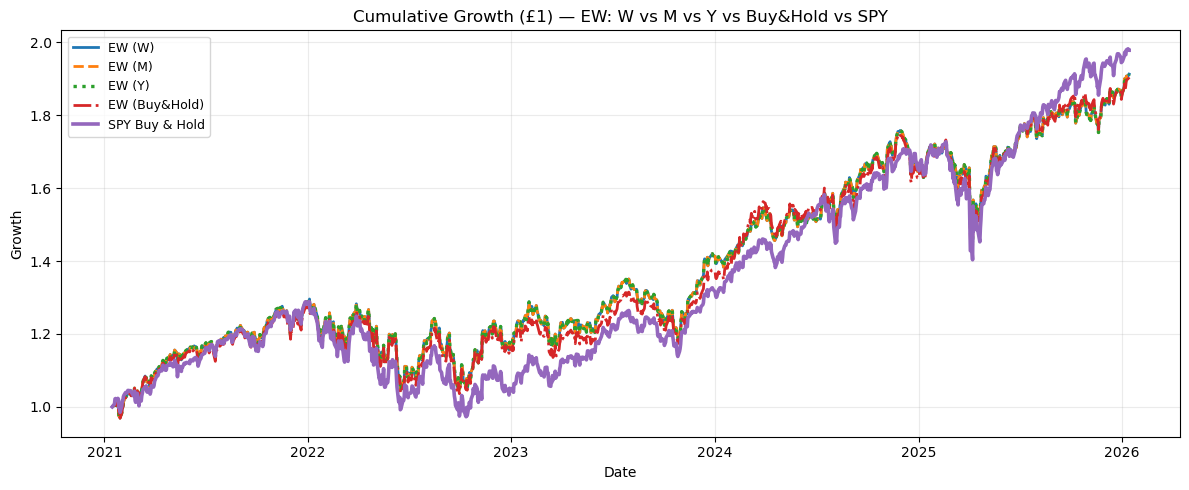

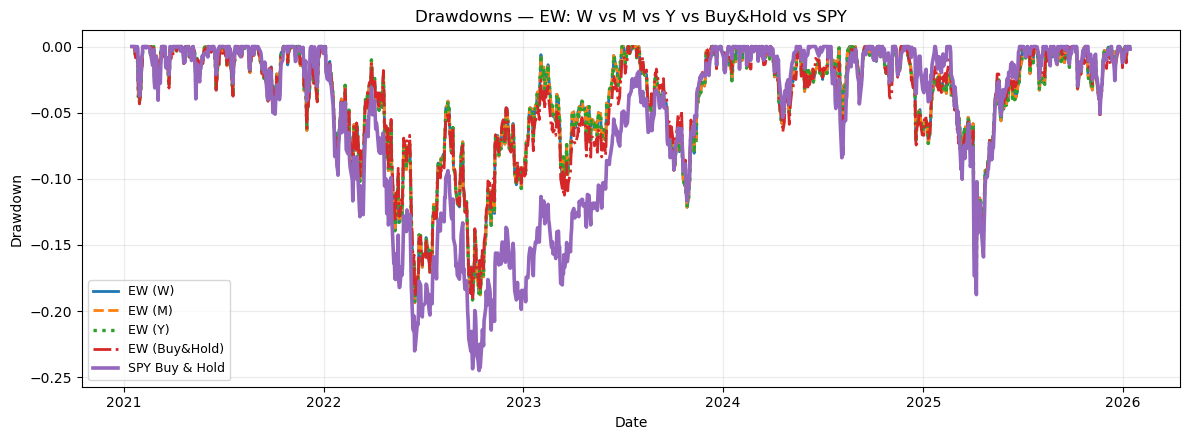

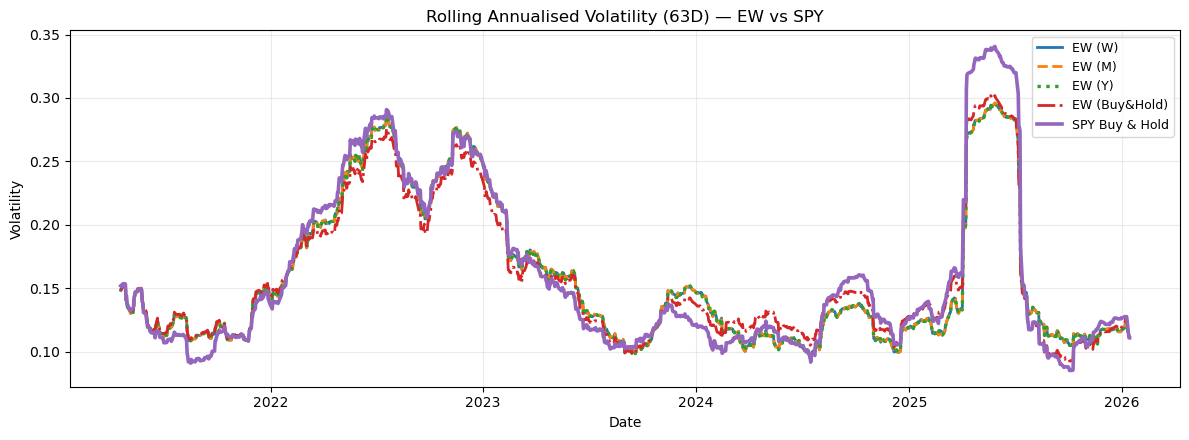

In [100]:

ew_cols = [
    "EW (W)", "EW (M)", "EW (Y)",
    "EW (Buy&Hold)",
    "SPY Buy & Hold"
]
ew_df = normalize_start_1(cum_df_pretty[ew_cols])

# 4) Plot with different linestyles so overlaps are visible
styles = {
    "EW (W)": {"linestyle": "-",  "linewidth": 2.0},
    "EW (M)": {"linestyle": "--", "linewidth": 2.0},
    "EW (Y)": {"linestyle": ":",  "linewidth": 2.4},
    "EW (Buy&Hold)": {"linestyle": "-.", "linewidth": 2.0},
    "SPY Buy & Hold": {"linestyle": "-", "linewidth": 2.6},
}

plt.figure(figsize=(12,5))
for c in ew_df.columns:
    s = ew_df[c].dropna()
    plt.plot(s.index, s.values, label=c, **styles.get(c, {"linewidth": 2.0}))
plt.title("Cumulative Growth (£1) — EW: W vs M vs Y vs Buy&Hold vs SPY")
plt.xlabel("Date"); plt.ylabel("Growth")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


# Drawdowns
ew_dd = ew_df / ew_df.cummax() - 1.0
plt.figure(figsize=(12,4.5))
for c in ew_dd.columns:
    s = ew_dd[c].dropna()
    plt.plot(s.index, s.values, label=c, **styles.get(c, {"linewidth": 1.5}))
plt.title("Drawdowns — EW: W vs M vs Y vs Buy&Hold vs SPY")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Rolling Vol
plt.figure(figsize=(12,4.5))
for c in ew_df.columns:
    vol = rolling_vol_from_cum(ew_df[c].dropna(), window=63).dropna()
    plt.plot(vol.index, vol.values, label=c, **styles.get(c, {"linewidth": 1.5}))
plt.title("Rolling Annualised Volatility (63D) — EW vs SPY")
plt.xlabel("Date"); plt.ylabel("Volatility")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Minimum Variance (MinVar): Frequency Comparison (W vs M vs Y)

Same idea: compare **W/M/Y rebalancing** for MinVar, plus:
- **Buy & Hold MinVar**
- **SPY Buy & Hold benchmark**


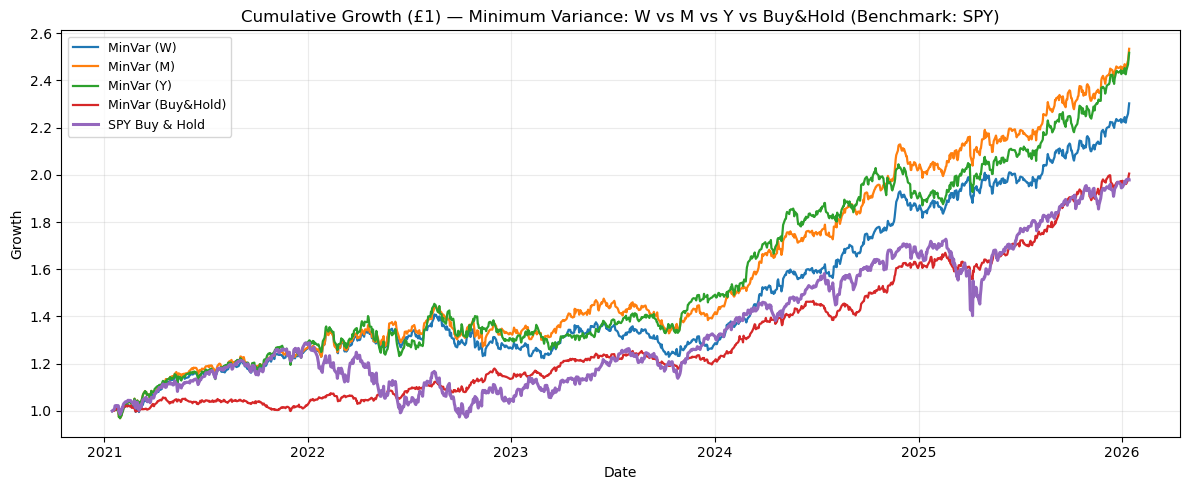

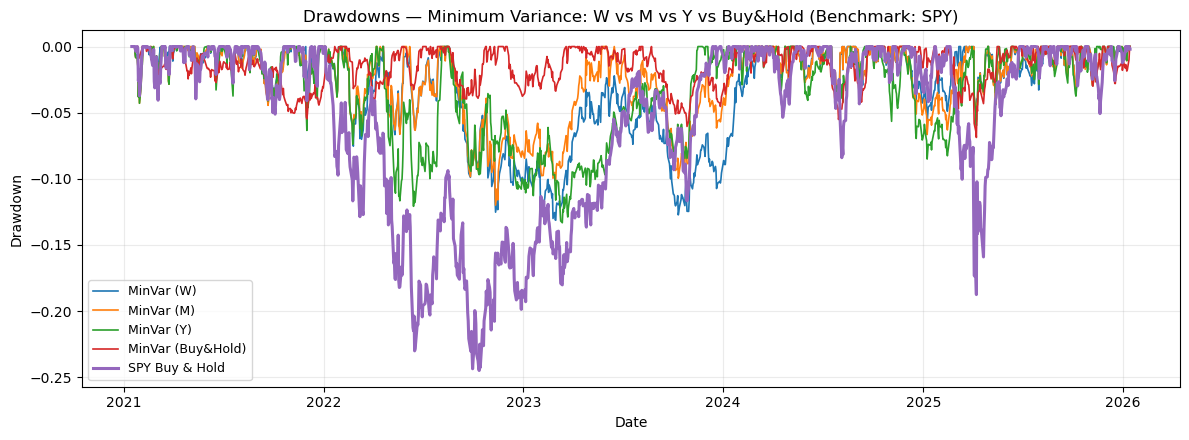

In [78]:
mv_cols = ["MinVar (W)", "MinVar (M)", "MinVar (Y)", "MinVar (Buy&Hold)", "SPY Buy & Hold"]
mv_df = normalize_start_1(cum_df_pretty[mv_cols])

plt.figure(figsize=(12,5))
for c in mv_df.columns:
    lw = 2.2 if "SPY" in c else 1.6
    plt.plot(mv_df[c].dropna(), linewidth=lw, label=c)
plt.title("Cumulative Growth (£1) — Minimum Variance: W vs M vs Y vs Buy&Hold (Benchmark: SPY)")
plt.xlabel("Date"); plt.ylabel("Growth")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

mv_dd = mv_df / mv_df.cummax() - 1.0
plt.figure(figsize=(12,4.5))
for c in mv_dd.columns:
    lw = 2.2 if "SPY" in c else 1.2
    plt.plot(mv_dd[c].dropna(), linewidth=lw, label=c)
plt.title("Drawdowns — Minimum Variance: W vs M vs Y vs Buy&Hold (Benchmark: SPY)")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Black–Litterman (BL): Frequency Comparison (W vs M vs Y)

Compare W/M/Y rebalancing for BL, plus:
- **Buy & Hold BL**
- **SPY Buy & Hold benchmark**


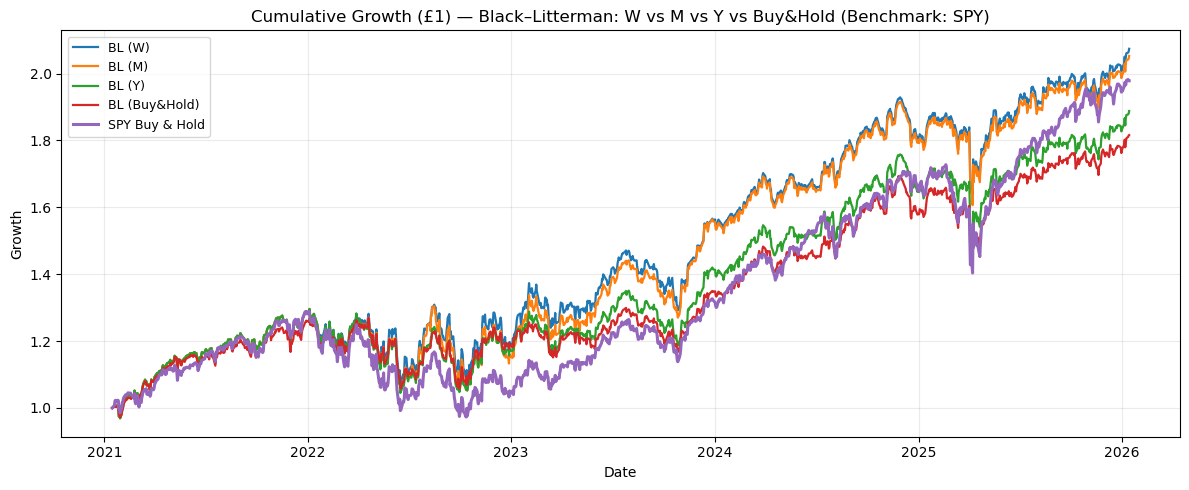

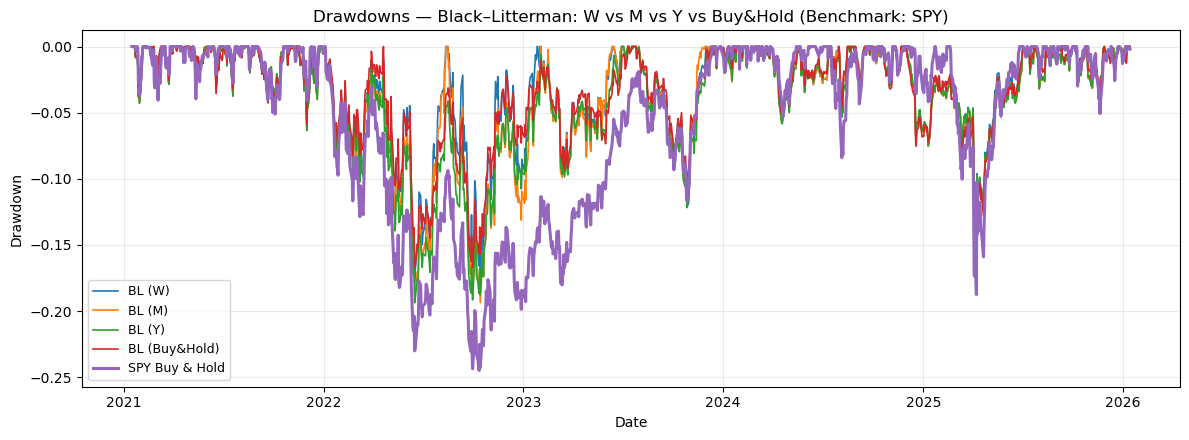

In [79]:
bl_cols = ["BL (W)", "BL (M)", "BL (Y)", "BL (Buy&Hold)", "SPY Buy & Hold"]
bl_df = normalize_start_1(cum_df_pretty[bl_cols])

plt.figure(figsize=(12,5))
for c in bl_df.columns:
    lw = 2.2 if "SPY" in c else 1.6
    plt.plot(bl_df[c].dropna(), linewidth=lw, label=c)
plt.title("Cumulative Growth (£1) — Black–Litterman: W vs M vs Y vs Buy&Hold (Benchmark: SPY)")
plt.xlabel("Date"); plt.ylabel("Growth")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

bl_dd = bl_df / bl_df.cummax() - 1.0
plt.figure(figsize=(12,4.5))
for c in bl_dd.columns:
    lw = 2.2 if "SPY" in c else 1.2
    plt.plot(bl_dd[c].dropna(), linewidth=lw, label=c)
plt.title("Drawdowns — Black–Litterman: W vs M vs Y vs Buy&Hold (Benchmark: SPY)")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


For each portfolio model, we compare different rebalancing frequencies (Weekly, Monthly, Yearly).
A Buy & Hold version of the same model is included to isolate the effect of rebalancing.
All results are benchmarked against the market portfolio (SPY Buy & Hold) to evaluate relative performance.


## Model Comparison at Fixed Rebalancing Frequency (Monthly)

To compare portfolio construction methods fairly, we fix the rebalancing
frequency to monthly and evaluate which model delivers superior
risk-adjusted performance relative to the market benchmark.


In [92]:
def plot_model_comparison(cum_df_pretty, freq="M"):
    """
    Compare EW, MinVar, BL at a fixed rebalance frequency.
    freq: 'W', 'M', or 'Y'
    """
    cols = [
        f"EW ({freq})",
        f"MinVar ({freq})",
        f"BL ({freq})",
        "SPY Buy & Hold"
    ]

    df = normalize_start_1(cum_df_pretty[cols])

    # ---- Cumulative Growth ----
    plt.figure(figsize=(12,5))
    for c in df.columns:
        lw = 2.2 if "SPY" in c else 1.6
        plt.plot(df[c].dropna(), linewidth=lw, label=c)

    plt.title(f"Model Comparison — {freq} Rebalancing (Benchmark: SPY)")
    plt.xlabel("Date")
    plt.ylabel("Growth")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # ---- Drawdowns ----
    dd = df / df.cummax() - 1
    plt.figure(figsize=(12,4.5))
    for c in dd.columns:
        lw = 2.2 if "SPY" in c else 1.2
        plt.plot(dd[c].dropna(), linewidth=lw, label=c)

    plt.title(f"Drawdowns — Model Comparison ({freq} Rebalance)")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    return df


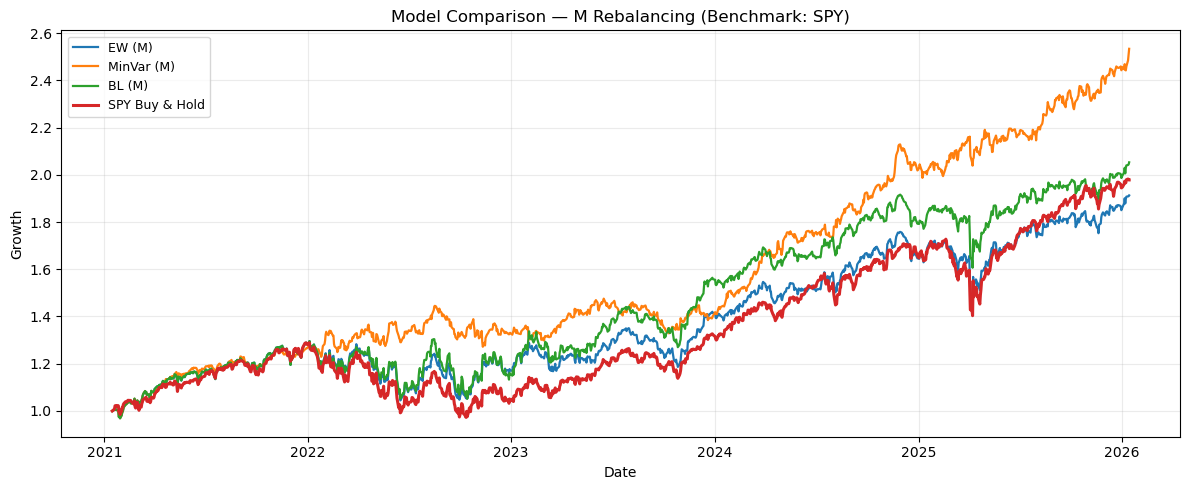

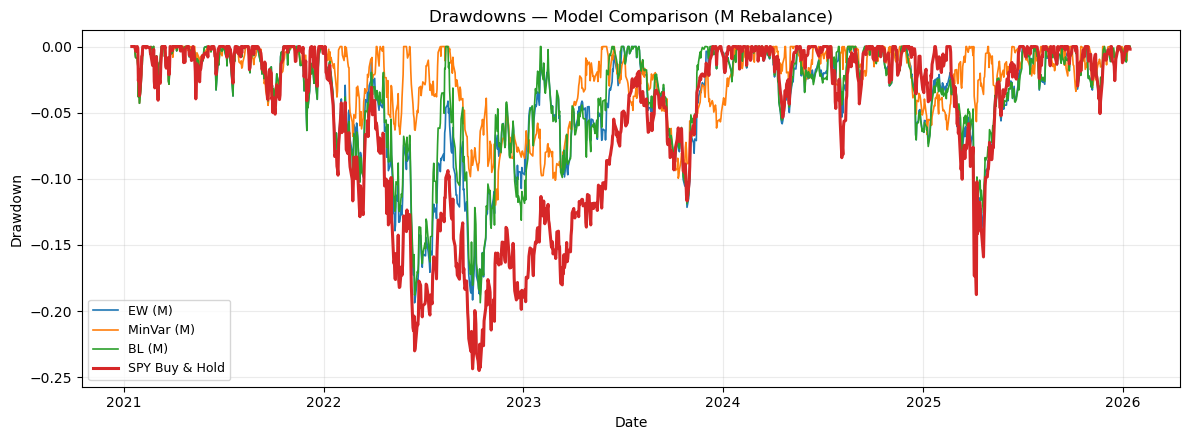

=== MODEL COMPARISON — MONTHLY ===


,CAGR (%),Ann Vol (%),Sharpe,Max Drawdown (%)
Strategy,,,,
MinVar (M),20.520929,12.155100,1.441447,-11.988637
BL (M),15.535895,17.296751,0.724754,-19.370563
SPY Buy & Hold,14.680690,17.092843,0.683367,-24.496400
EW (M),13.908484,16.616559,0.656483,-19.376256


In [96]:
df_model_M = plot_model_comparison(cum_df_pretty, freq="M")
print("=== MODEL COMPARISON — MONTHLY ===")
display(perf_table_pro_per_col(df_model_M, rf=risk_free_rate_annual))

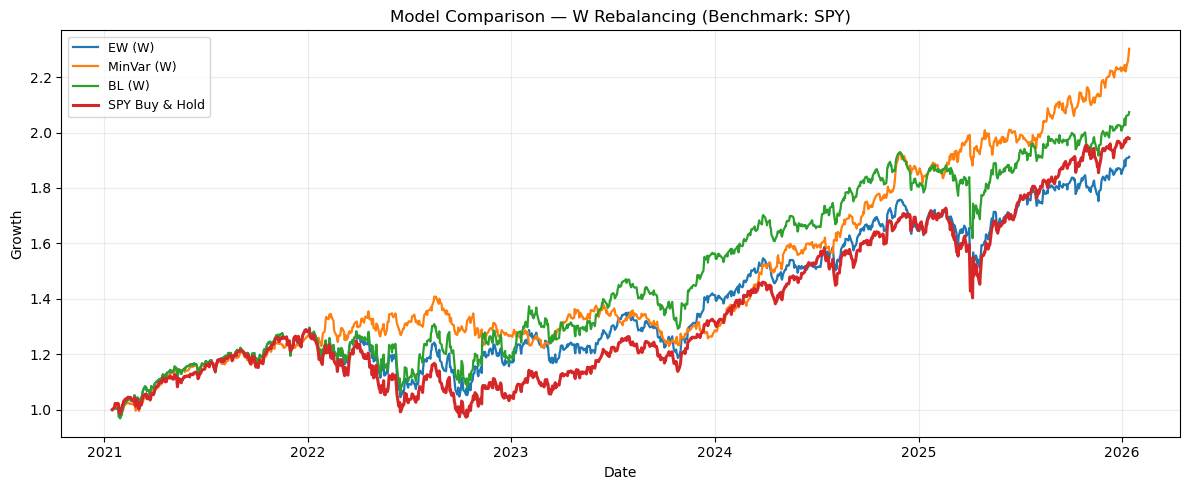

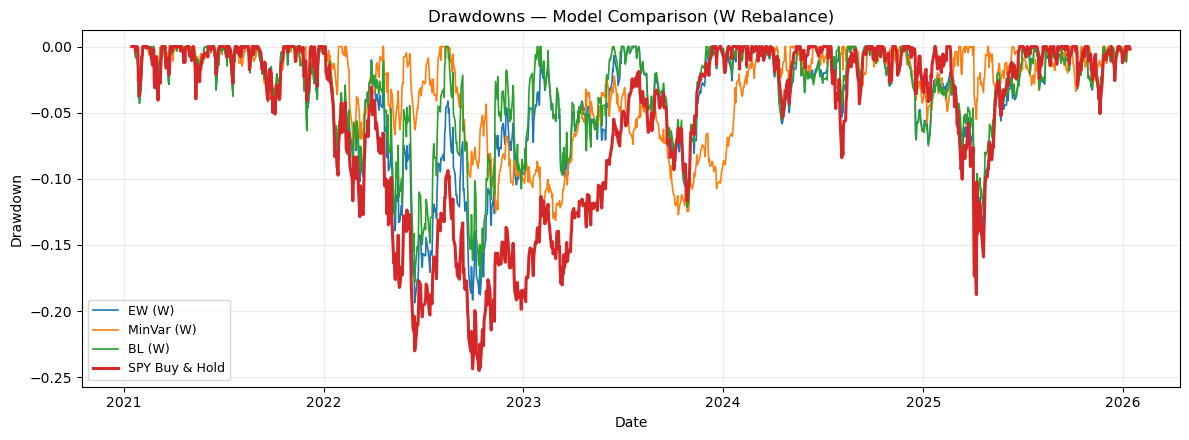

=== MODEL COMPARISON — WEEKLY ===


,CAGR (%),Ann Vol (%),Sharpe,Max Drawdown (%)
Strategy,,,,
MinVar (W),18.227690,11.879321,1.281865,-13.132461
BL (W),15.773746,17.473082,0.731053,-17.819204
SPY Buy & Hold,14.680690,17.092843,0.683367,-24.496400
EW (W),13.908484,16.616559,0.656483,-19.376256


In [95]:
df_model_W = plot_model_comparison(cum_df_pretty, freq="W")
print("=== MODEL COMPARISON — WEEKLY ===")
display(perf_table_pro_per_col(df_model_W, rf=risk_free_rate_annual))

### Select best model + frequency

In [98]:
TRADING_DAYS = 252

def compute_metrics_from_curve(curve: pd.Series, rf=0.03) -> dict:
    s = curve.dropna()
    if len(s) < 50:
        return {}

    r = s.pct_change().dropna()
    if len(r) < 50:
        return {}

    cagr = s.iloc[-1] ** (TRADING_DAYS / len(s)) - 1.0
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = (cagr - rf) / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0]
    dvol = downside.std() * np.sqrt(TRADING_DAYS) if len(downside) > 10 else np.nan

    dd = s / s.cummax() - 1
    mdd = dd.min()

    return {
        "CAGR (%)": cagr * 100,
        "Ann Vol (%)": ann_vol * 100,
        "Sharpe": sharpe,
        "Max Drawdown (%)": mdd * 100
    }


def build_metrics_table(cum_df_pretty: pd.DataFrame, rf=0.03) -> pd.DataFrame:
    rows = []
    for col in cum_df_pretty.columns:
        m = compute_metrics_from_curve(cum_df_pretty[col], rf=rf)
        if m:
            rows.append([col, *m.values()])
    metrics = pd.DataFrame(
        rows,
        columns=["Strategy"] + list(compute_metrics_from_curve(cum_df_pretty.iloc[:,0].dropna(), rf=rf).keys())
    ).set_index("Strategy")
    return metrics


def parse_model_and_freq(name: str):
    """
    Works with names like:
      'EW (W)', 'MinVar (M)', 'BL (Y)', 'EW (Buy&Hold)', 'SPY (Buy&Hold)'
    Returns model, freq.
    """
    if name.startswith("SPY"):
        return "SPY", "BH"

    if name.startswith("EW"):
        model = "EW"
    elif name.startswith("MinVar"):
        model = "MinVar"
    elif name.startswith("BL"):
        model = "BL"
    else:
        model = "Other"

    # frequency
    if "(W)" in name:
        freq = "W"
    elif "(M)" in name:
        freq = "M"
    elif "(Y)" in name:
        freq = "Y"
    elif "Buy&Hold" in name or "(Buy&Hold)" in name:
        freq = "BH"
    else:
        freq = "?"

    return model, freq


def pick_best(metrics: pd.DataFrame, rank_by="Sharpe"):
    """
    Select best strategies EXCLUDING:
    - SPY
    - Buy & Hold (BH)

    Only rebalanced W/M/Y strategies are considered.
    """
    m = metrics.copy()

    # Remove invalid values
    m = m.replace([np.inf, -np.inf], np.nan).dropna(subset=[rank_by])

    # Add model/frequency tags
    model_freq = m.index.to_series().apply(parse_model_and_freq)
    m["Model"] = [x[0] for x in model_freq]
    m["Freq"]  = [x[1] for x in model_freq]

    # 🚫 Exclude SPY and Buy & Hold
    m = m[
        (m["Model"].isin(["EW", "MinVar", "BL"])) &
        (m["Freq"].isin(["W", "M", "Y"]))
    ]

    # ---- Best overall (all models & frequencies) ----
    best_overall = m.sort_values(rank_by, ascending=False).head(1)

    # ---- Best per model (EW / MinVar / BL) ----
    best_per_model = (
        m.sort_values(rank_by, ascending=False)
         .groupby("Model")
         .head(1)
         .sort_values(rank_by, ascending=False)
    )

    # ---- Best frequency per model ----
    best_freq_per_model = (
        m.sort_values(rank_by, ascending=False)
         .groupby(["Model", "Freq"])
         .head(1)
         .sort_values(rank_by, ascending=False)
    )

    return best_overall, best_per_model, best_freq_per_model, m


# -----------------------------
# RUN
# -----------------------------
metrics_all = build_metrics_table(cum_df_pretty, rf=risk_free_rate_annual)

best_overall, best_per_model, best_freq_per_model, metrics_clean = pick_best(
    metrics_all,
    rank_by="Sharpe"   # or "Calmar"
)

print("=== Best Overall (Rebalanced Only) ===")
display(best_overall)

print("\n=== Best Per Model (Rebalanced Only) ===")
display(best_per_model)

print("\n=== Best Frequency Per Model ===")
display(best_freq_per_model)

print("\n=== Full Ranked Table (Rebalanced Strategies Only) ===")
display(metrics_clean.sort_values("Sharpe", ascending=False))


=== Best Overall (Rebalanced Only) ===


,CAGR (%),Ann Vol (%),Sharpe,Max Drawdown (%),Model,Freq
Strategy,,,,,,
MinVar (M),20.520929,12.1551,1.441447,-11.988637,MinVar,M



=== Best Per Model (Rebalanced Only) ===


,CAGR (%),Ann Vol (%),Sharpe,Max Drawdown (%),Model,Freq
Strategy,,,,,,
MinVar (M),20.520929,12.155100,1.441447,-11.988637,MinVar,M
BL (W),15.773746,17.473082,0.731053,-17.819204,BL,W
EW (W),13.908484,16.616559,0.656483,-19.376256,EW,W



=== Best Frequency Per Model ===


,CAGR (%),Ann Vol (%),Sharpe,Max Drawdown (%),Model,Freq
Strategy,,,,,,
MinVar (M),20.520929,12.155100,1.441447,-11.988637,MinVar,M
MinVar (W),18.227690,11.879321,1.281865,-13.132461,MinVar,W
MinVar (Y),20.357800,13.595983,1.276686,-13.323603,MinVar,Y
BL (W),15.773746,17.473082,0.731053,-17.819204,BL,W
BL (M),15.535895,17.296751,0.724754,-19.370563,BL,M
EW (W),13.908484,16.616559,0.656483,-19.376256,EW,W
EW (M),13.908484,16.616559,0.656483,-19.376256,EW,M
EW (Y),13.908484,16.616559,0.656483,-19.376256,EW,Y
BL (Y),13.610218,16.310563,0.650512,-19.376256,BL,Y



=== Full Ranked Table (Rebalanced Strategies Only) ===


,CAGR (%),Ann Vol (%),Sharpe,Max Drawdown (%),Model,Freq
Strategy,,,,,,
MinVar (M),20.520929,12.155100,1.441447,-11.988637,MinVar,M
MinVar (W),18.227690,11.879321,1.281865,-13.132461,MinVar,W
MinVar (Y),20.357800,13.595983,1.276686,-13.323603,MinVar,Y
BL (W),15.773746,17.473082,0.731053,-17.819204,BL,W
BL (M),15.535895,17.296751,0.724754,-19.370563,BL,M
EW (W),13.908484,16.616559,0.656483,-19.376256,EW,W
EW (M),13.908484,16.616559,0.656483,-19.376256,EW,M
EW (Y),13.908484,16.616559,0.656483,-19.376256,EW,Y
BL (Y),13.610218,16.310563,0.650512,-19.376256,BL,Y


In [86]:
final_choice = best_per_model[["Sharpe", "CAGR (%)", "Max Drawdown (%)"]]
display(final_choice)


,Sharpe,CAGR (%),Max Drawdown (%)
Strategy,,,
MinVar (Buy&Hold),1.497492,14.990811,-6.874652
BL (W),0.731053,15.773746,-17.819204
EW (M),0.656483,13.908484,-19.376256


In [101]:
def extract_model_freq(strategy_name: str):
    if strategy_name.startswith("SPY"):
        return "SPY", "Buy&Hold"

    if strategy_name.startswith("EW"):
        model = "Equal Weight"
    elif strategy_name.startswith("MinVar"):
        model = "Minimum Variance"
    elif strategy_name.startswith("BL"):
        model = "Black–Litterman"
    else:
        model = "Other"

    if "(W)" in strategy_name:
        freq = "Weekly"
    elif "(M)" in strategy_name:
        freq = "Monthly"
    elif "(Y)" in strategy_name:
        freq = "Yearly"
    elif "Buy&Hold" in strategy_name:
        freq = "Buy&Hold"
    else:
        freq = "Unknown"

    return model, freq


In [102]:
results_master = metrics_all.copy()

# Extract model and frequency
results_master["Model"] = results_master.index.map(lambda x: extract_model_freq(x)[0])
results_master["Rebalance Frequency"] = results_master.index.map(lambda x: extract_model_freq(x)[1])

# Reorder columns nicely
results_master = results_master[
    ["Model", "Rebalance Frequency", "CAGR (%)", "Ann Vol (%)", "Sharpe", "Max Drawdown (%)"]
]

# Sort for readability
results_master = results_master.sort_values(
    by=["Model", "Rebalance Frequency"]
)

display(results_master.head(10))


,Model,Rebalance Frequency,CAGR (%),Ann Vol (%),Sharpe,Max Drawdown (%)
Strategy,,,,,,
BL (Buy&Hold),Black–Litterman,Buy&Hold,12.725495,14.817663,0.656345,-16.675089
BL (M),Black–Litterman,Monthly,15.535895,17.296751,0.724754,-19.370563
BL (W),Black–Litterman,Weekly,15.773746,17.473082,0.731053,-17.819204
BL (Y),Black–Litterman,Yearly,13.610218,16.310563,0.650512,-19.376256
EW (Buy&Hold),Equal Weight,Buy&Hold,13.736956,16.475211,0.651704,-19.008138
EW (M),Equal Weight,Monthly,13.908484,16.616559,0.656483,-19.376256
EW (W),Equal Weight,Weekly,13.908484,16.616559,0.656483,-19.376256
EW (Y),Equal Weight,Yearly,13.908484,16.616559,0.656483,-19.376256
MinVar (Buy&Hold),Minimum Variance,Buy&Hold,14.990811,8.007262,1.497492,-6.874652


In [104]:
results_master.to_csv(
    "aligned_returns.csv",
    index_label="Strategy"
)
